In [1]:
from matcher import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

/lv_local/home/omer.y/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dset_path = "data/er_magellan/Structured/Amazon-Google/train.txt"
clean_left, clean_right, labels = getData(dset_path)
labels = [int(l) for l in labels]

In [3]:
_, bert_logits = label_by_bert(clean_left, clean_right)

In [4]:
def classiy(logits, threshold=0.5):
    return [1 if x > threshold else 0 for x in logits]

def entropy(logits, eps=1e-5):
    clipped_logits = np.clip(logits, eps, 1-eps)
    return [-x*np.log(x) - (1-x)*np.log(1-x) for x in clipped_logits]

def clalculate_classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return accuracy, f1, precision, recall

def top_percentile(logits, q):
    threshold = np.percentile(logits, q) # gets the q-th percentile
    indices = np.where(logits >= threshold)[0] # gets the indices of the top q% of logits
    return threshold, indices

def bottom_precentile(logits, q):
    threshold = np.percentile(logits, 100 - q) # gets the (100 - q)-th percentile
    indices = np.where(logits <= threshold)[0] # gets the indices of the bottom q% of logits
    return threshold, indices


In [13]:
all_pred = classiy(bert_logits, threshold=0.8)
all_entropy = entropy(bert_logits)


In [14]:
precs = [10, 20, 30, 40, 50, 60, 70, 80, 90]
acc, f1_arr, prec, rec, thresh = [], [], [], [], []
for p in precs:
    threshold, indices = top_percentile(all_entropy, p)
    y_true = [labels[i] for i in indices]
    y_pred = [all_pred[i] for i in indices]
    accuracy, f1, precision, recall = clalculate_classification_metrics(y_true, y_pred)
    acc.append(accuracy)
    # f1_arr.append(f1)
    # prec.append(precision)
    rec.append(recall)
    thresh.append(threshold)

/lv_local/home/omer.y/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/lv_local/home/omer.y/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/lv_local/home/omer.y/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/lv_local/home/omer.y/

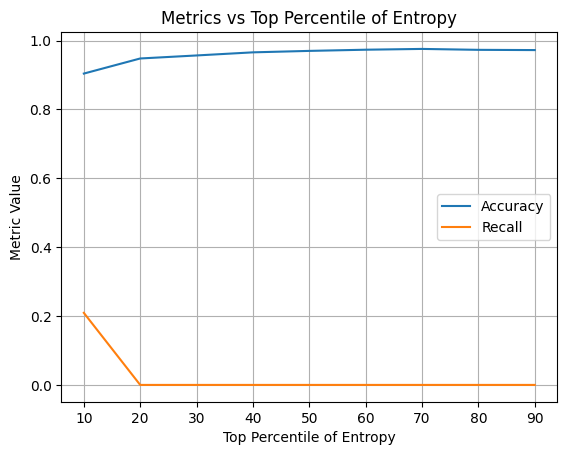

In [15]:
fig, ax = plt.subplots()
ax.plot(precs, acc, label='Accuracy')
# ax.plot(precs, f1_arr, label='F1')
# ax.plot(precs, prec, label='Precision')
ax.plot(precs, rec, label='Recall')
ax.legend()
plt.xlabel('Top Percentile of Entropy')
plt.ylabel('Metric Value')
plt.title('Metrics vs Top Percentile of Entropy')
plt.grid()
plt.show()

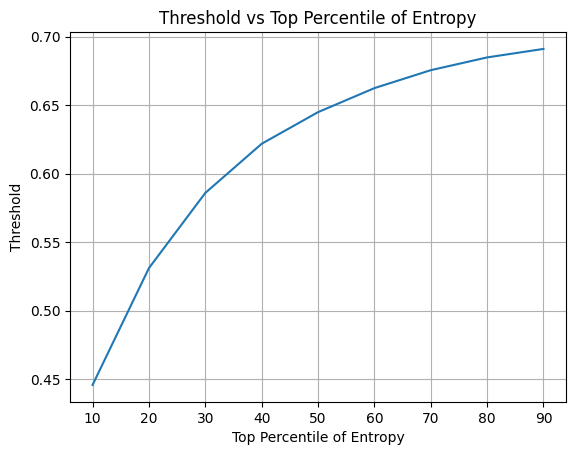

In [16]:
plt.plot(precs, thresh)
plt.xlabel('Top Percentile of Entropy')
plt.ylabel('Threshold')
plt.title('Threshold vs Top Percentile of Entropy')
plt.grid()
plt.show()

In [17]:
b_acc, b_f1_arr, b_prec, b_rec, b_thresh = [], [], [], [], []
for p in precs:
    threshold, indices = bottom_precentile(all_entropy, p)
    y_true = [labels[i] for i in indices]
    y_pred = [all_pred[i] for i in indices]
    accuracy, f1, precision, recall = clalculate_classification_metrics(y_true, y_pred)
    b_acc.append(accuracy)
    b_f1_arr.append(f1)
    b_prec.append(precision)
    b_rec.append(recall)
    b_thresh.append(threshold)

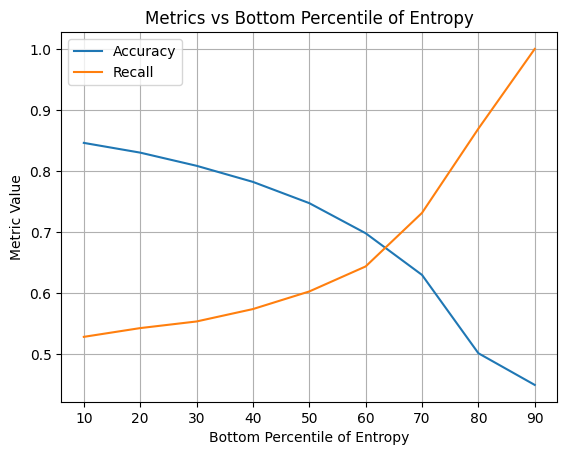

In [18]:
fig, ax = plt.subplots()
ax.plot(precs, b_acc, label='Accuracy')
# ax.plot(precs, b_f1_arr, label='F1')
# ax.plot(precs, b_prec, label='Precision')
ax.plot(precs, b_rec, label='Recall')
ax.legend()
plt.xlabel('Bottom Percentile of Entropy')
plt.ylabel('Metric Value')
plt.title('Metrics vs Bottom Percentile of Entropy')
plt.grid()
plt.show()

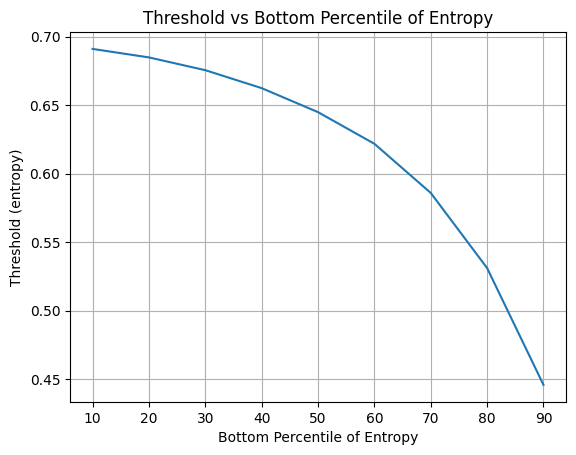

In [19]:
plt.plot(precs, b_thresh)
plt.xlabel('Bottom Percentile of Entropy')
plt.ylabel('Threshold (entropy)')
plt.title('Threshold vs Bottom Percentile of Entropy')
plt.grid()
plt.show()